In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d sriharshaeedala/financial-fraud-detection-dataset
!unzip financial-fraud-detection-dataset.zip

mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open financial-fraud-detection-dataset.zip, financial-fraud-detection-dat

1. Load the Dataset

In [ ]:
# ===== 1. معالجة البيانات =====
df = pd.read_csv("Synthetic_Financial_datasets_log.csv")

# حذف الأعمدة النصية غير المفيدة
df.drop(columns=['nameOrig', 'nameDest'], inplace=True, errors='ignore')

# تنظيف النصوص
df.columns = df.columns.str.strip()
df['type'] = df['type'].str.lower().str.strip()

# ✅ تحويل العمود النصي إلى متغيرات رقمية (One-Hot Encoding)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# ===== 2. فصل المتغيرات =====
X = df.drop(columns=['isFraud'])
y = df['isFraud']
# تحويل القيم المنطقية (True/False) إلى أرقام (0/1)
X = X.astype(float)


# ===== 3. تحجيم القيم الرقمية فقط =====
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# نحدد فقط الأعمدة الرقمية للتحجيم
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("تم التحجيم بنجاح ✅")
print(X.head())


تم التحجيم بنجاح ✅
       step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0 -1.703042 -0.281560      -0.229810       -0.237622       -0.323814   
1 -1.703042 -0.294767      -0.281359       -0.285812       -0.323814   
2 -1.703042 -0.297555      -0.288654       -0.292442       -0.323814   
3 -1.703042 -0.297555      -0.288654       -0.292442       -0.317582   
4 -1.703042 -0.278532      -0.274329       -0.282221       -0.323814   

   newbalanceDest  isFlaggedFraud  type_cash_out  type_debit  type_payment  \
0       -0.333411       -0.001586      -0.736484    -0.08096      1.399036   
1       -0.333411       -0.001586      -0.736484    -0.08096      1.399036   
2       -0.333411       -0.001586      -0.736484    -0.08096     -0.714778   
3       -0.333411       -0.001586       1.357803    -0.08096     -0.714778   
4       -0.333411       -0.001586      -0.736484    -0.08096      1.399036   

   type_transfer  
0      -0.302345  
1      -0.302345  
2       3.307478  
3  

# Cross-Validation with XGBoost + scale_pos_weight + Threshold Optimization + Plots



===== Fold 1 =====
Training data: 5,083,104 Non-Fraud | 6,557 Fraud
Optimal Threshold (F2): 0.973 | Precision=0.870 | Recall=0.921 | F2=0.911
ROC-AUC: 0.9994 | PR-AUC: 0.9640
              precision    recall  f1-score   support

   Not Fraud     0.9999    0.9998    0.9999   1270776
       Fraud     0.8699    0.9213    0.8949      1640

    accuracy                         0.9997   1272416
   macro avg     0.9349    0.9606    0.9474   1272416
weighted avg     0.9997    0.9997    0.9997   1272416

Confusion Matrix:
 [[1270550     226]
 [    129    1511]]

===== Fold 2 =====
Training data: 5,083,104 Non-Fraud | 6,557 Fraud
Optimal Threshold (F2): 0.943 | Precision=0.802 | Recall=0.951 | F2=0.917
ROC-AUC: 0.9997 | PR-AUC: 0.9688
              precision    recall  f1-score   support

   Not Fraud     0.9999    0.9997    0.9998   1270776
       Fraud     0.8024    0.9506    0.8702      1640

    accuracy                         0.9996   1272416
   macro avg     0.9012    0.9752    0.9350  

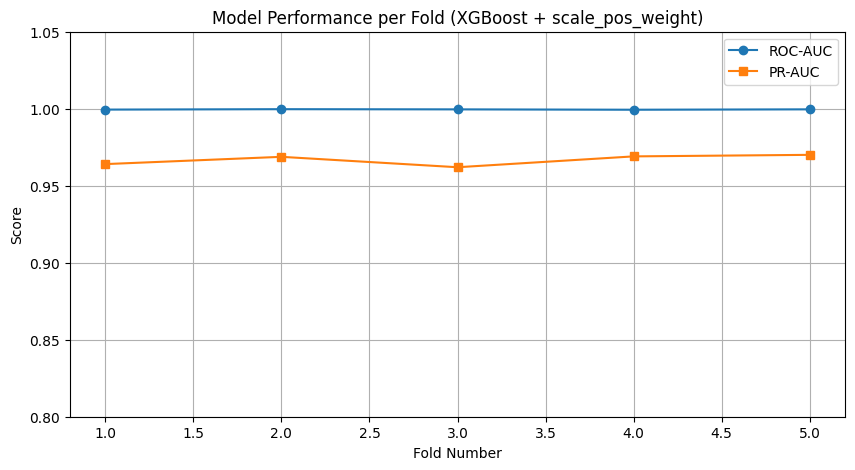

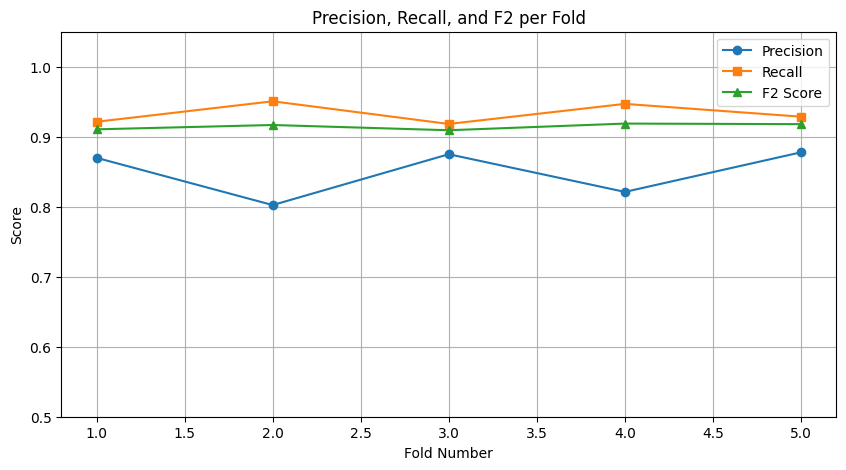

In [ ]:
# ============================================
# Cross-Validation with XGBoost + scale_pos_weight + Threshold Optimization + Plots
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)
from xgboost import XGBClassifier

# ===== 1. Load & Preprocess Data =====
df = pd.read_csv("Synthetic_Financial_datasets_log.csv")

# حذف الأعمدة غير المفيدة
df.drop(columns=['nameOrig', 'nameDest'], inplace=True, errors='ignore')
df.drop_duplicates(inplace=True)

# تنظيف النصوص
df.columns = df.columns.str.strip()
df['type'] = df['type'].str.lower().str.strip()

# One-hot encoding
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# تحجيم الأعمدة الرقمية
cols_to_scale = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
scaler = RobustScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# فصل الميزات والهدف
X = df.drop(columns=['isFraud'])
y = df['isFraud']

X = X.astype(float)

# ===== 2. إعداد الكروس فالديشن =====
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

# ⭐⭐⭐ أهم إضافة: مصفوفات التوقعات خارج الفولد ⭐⭐⭐
oof_proba = np.zeros(len(y))
oof_pred  = np.zeros(len(y))

def pick_best_threshold(y_true, y_probs, mode="F2", recall_target=0.90):
    ps, rs, ths = precision_recall_curve(y_true, y_probs)
    ths = np.append(ths, 1.0)
    if mode == "F2":
        beta = 2.0
        f = (1 + beta**2) * (ps * rs) / ((beta**2) * ps + rs + 1e-9)
        i = np.nanargmax(f)
        return ths[i], ps[i], rs[i], f[i], "F2"
    elif mode == "min_recall":
        mask = rs >= recall_target
        if not np.any(mask):
            raise ValueError(f"No threshold meets Recall ≥ {recall_target}")
        i = np.argmax(ps[mask])
        return ths[mask][i], ps[mask][i], rs[mask][i], None, f"Recall≥{recall_target}"

# ===== 3. تنفيذ الكروس فالديشن =====
fold = 1
for train_idx, test_idx in skf.split(X, y):
    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    n_nonfraud = (y_train == 0).sum()
    n_fraud    = (y_train == 1).sum()
    print(f"Training data: {n_nonfraud:,} Non-Fraud | {n_fraud:,} Fraud")

    spw = n_nonfraud / max(n_fraud, 1)

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=spw,
        eval_metric="aucpr"
    )

    model.fit(X_train, y_train)

    # 🔥 التنبؤ لاحظي إنه على X_test = بيانات ما شافها الموديل
    y_probs = model.predict_proba(X_test)[:, 1]

    # ⭐⭐⭐ هنا نخزن التوقعات بشكل صحيح ⭐⭐⭐
    oof_proba[test_idx] = y_probs

    thr, P, R, F, crit = pick_best_threshold(y_test, y_probs, mode="F2")
    y_pred = (y_probs >= thr).astype(int)

    # ⭐⭐⭐ نخزن التوقع النهائي 0/1 ⭐⭐⭐
    oof_pred[test_idx]  = y_pred

    roc = roc_auc_score(y_test, y_probs)
    pr_auc = average_precision_score(y_test, y_probs)

    print(f"Optimal Threshold ({crit}): {thr:.3f} | Precision={P:.3f} | Recall={R:.3f} | F2={F:.3f}")
    print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Fraud","Fraud"], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    fold_results.append({
        "Fold": fold,
        "Threshold": thr,
        "Precision": P,
        "Recall": R,
        "F2": F,
        "ROC-AUC": roc,
        "PR-AUC": pr_auc,
        "Fraud_train": n_fraud,
        "NonFraud_train": n_nonfraud
    })

    fold += 1

print("\n🎯 Generated out-of-fold predictions in oof_proba & oof_pred")

# ===== 4. تحويل النتائج إلى DataFrame =====
fold_df = pd.DataFrame(fold_results)
print("\n===== Cross-Validation Summary =====")
print(fold_df)
print("\nMean ROC-AUC:", fold_df["ROC-AUC"].mean())
print("Mean PR-AUC :", fold_df["PR-AUC"].mean())
print("Mean F2      :", fold_df["F2"].mean())

# ===== 5. الرسوم البيانية =====
plt.figure(figsize=(10, 5))
plt.plot(fold_df["Fold"], fold_df["ROC-AUC"], marker='o', label="ROC-AUC")
plt.plot(fold_df["Fold"], fold_df["PR-AUC"], marker='s', label="PR-AUC")
plt.title("Model Performance per Fold (XGBoost + scale_pos_weight)")
plt.xlabel("Fold Number")
plt.ylabel("Score")
plt.ylim(0.8, 1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(fold_df["Fold"], fold_df["Precision"], marker='o', label="Precision")
plt.plot(fold_df["Fold"], fold_df["Recall"], marker='s', label="Recall")
plt.plot(fold_df["Fold"], fold_df["F2"], marker='^', label="F2 Score")
plt.title("Precision, Recall, and F2 per Fold")
plt.xlabel("Fold Number")
plt.ylabel("Score")
plt.ylim(0.5, 1.05)
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
from xgboost import XGBClassifier

# تدريب النموذج على كامل البيانات X , y
model_full = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1]),
    eval_metric="aucpr"
)

model_full.fit(X, y)

print("✔ Model Retrained on Full Dataset")


✔ Model Retrained on Full Dataset


In [ ]:
# 🔮 التنبؤ باحتمالية الاحتيال لكل صف في X
y_proba_full = model_full.predict_proba(X)[:, 1]   # احتمال الاحتيال

# نحط عتبة (threshold) لتحويل الاحتمال إلى 0/1
THRESH = 0.975   # تقدرين تغيّرينها مثلاً لـ 0.7 أو تستخدمين أفضل عتبة من الكروس فالديشن

y_pred_full = (y_proba_full >= THRESH).astype(int)   # 1 = Fraud, 0 = Not Fraud

print("Prediction samples (0/1):", y_pred_full[:10])
print("Probability samples:", y_proba_full[:10])


Prediction samples (0/1): [0 0 1 1 0 0 0 0 0 0]
Probability samples: [1.8183455e-06 6.5246254e-06 9.9978715e-01 9.9933076e-01 2.3618200e-06
 7.8080274e-07 9.9234921e-07 1.0549347e-06 2.6808790e-04 5.9746003e-07]


In [ ]:
# ============================================
#  حساب خسارة الاحتيال (Total / Prevented / Missed)
#  وتجهيز ملف جاهز لـ Power BI
# ============================================

import numpy as np

# 1) ننسخ الداتا الأصلية عشان نضيف عليها الأعمدة الجديدة
df_results = df.copy()

# 2) نضيف الأعمدة الخاصة بتنبؤ الموديل
df_results["y_true"] = y.values
df_results["fraud_proba"] = oof_proba
df_results["fraud_pred"]  = oof_pred.astype(int)


# 3) نحدد اسم عمود المبلغ في الداتا
AMOUNT_COL = "amount"   # لو عمود المبلغ اسمه غير غيّري الاسم هنا

# 4) نحسب خسارة الاحتيال الحقيقية (بس لما y_true = 1)
df_results["fraud_loss"] = np.where(
    df_results["y_true"] == 1,
    df_results[AMOUNT_COL],
    0.0
)

# 5) خسارة احتيال تم منعها (True Positives)
df_results["prevented_loss"] = np.where(
    (df_results["y_true"] == 1) & (df_results["fraud_pred"] == 1),
    df_results[AMOUNT_COL],
    0.0
)

# 6) خسارة احتيال فاتت على الموديل (False Negatives)
df_results["missed_loss"] = np.where(
    (df_results["y_true"] == 1) & (df_results["fraud_pred"] == 0),
    df_results[AMOUNT_COL],
    0.0
)

# 7) تقدري برضه تضيفي فلاغ يوضح حالة كل عملية
def classify_row(row):
    if row["y_true"] == 1 and row["fraud_pred"] == 1:
        return "Detected Fraud"      # احتيال اكتشفه الموديل
    elif row["y_true"] == 1 and row["fraud_pred"] == 0:
        return "Missed Fraud"        # احتيال فات الموديل
    elif row["y_true"] == 0 and row["fraud_pred"] == 1:
        return "False Alarm"         # إنذار كاذب
    else:
        return "Legit Transaction"   # عملية سليمة

df_results["fraud_case_type"] = df_results.apply(classify_row, axis=1)

# 8) نطبع شوية أرقام للتأكد
print("Total fraud loss        :", df_results["fraud_loss"].sum())
print("Prevented fraud loss    :", df_results["prevented_loss"].sum())
print("Missed (undetected) loss:", df_results["missed_loss"].sum())

# 9) حفظ الملف لـ Power BI
output_file = "fraud_predictions_for_powerbi.csv"
df_results.to_csv(output_file, index=False)
print(f"\n✅ تم حفظ الملف: {output_file}")


Total fraud loss        : 57809.86428181304
Prevented fraud loss    : 57664.09751273801
Missed (undetected) loss: 145.76676907501633

✅ تم حفظ الملف: fraud_predictions_for_powerbi.csv


In [ ]:
from google.colab import files

files.download("fraud_predictions_for_powerbi.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

# نسخ البيانات الأصلية
dashboard_df = df.copy()

# إضافة التوقعات الفعلية
dashboard_df["Predicted_Label"] = oof_pred.astype(int)
dashboard_df["Fraud_Probability"] = oof_proba


# تقسيم المخاطر لثلاث مستويات
dashboard_df["Risk_Level"] = np.where(
    y_proba_full >= 0.80, "High",
    np.where(y_proba_full >= 0.40, "Medium", "Low")
)

# ترتيب الأعمدة (اختياري)
cols = ["isFraud", "Predicted_Label", "Fraud_Probability", "Risk_Level"] + \
       [c for c in dashboard_df.columns if c not in ["isFraud","Predicted_Label","Fraud_Probability","Risk_Level"]]

dashboard_df = dashboard_df[cols]

# حفظ الملف
dashboard_df.to_csv("fraud_dashboard_dataset.csv", index=False)
print("✔️ Saved: fraud_dashboard_dataset.csv")
dashboard_df.head()


✔️ Saved: fraud_dashboard_dataset.csv


,isFraud,Predicted_Label,Fraud_Probability,Risk_Level,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,type_cash_out,type_debit,type_payment,type_transfer
0,0,0,4.680832e-07,Low,1,-0.333030,1.452751,1.110912,-0.140784,-0.193101,0,False,False,True,False
1,0,0,1.596113e-06,Low,1,-0.373858,0.065511,0.134343,-0.140784,-0.193101,0,False,False,True,False
2,1,1,9.994828e-01,High,1,-0.382476,-0.130788,0.000000,-0.140784,-0.193101,0,False,False,False,True
3,1,1,9.957482e-01,High,1,-0.382476,-0.130788,0.000000,-0.118326,-0.193101,0,True,False,False,False
4,0,0,6.024039e-07,Low,1,-0.323669,0.254701,0.207120,-0.140784,-0.193101,0,False,False,True,False


In [ ]:

# ===== اشتقاق ميزات زمنية من step على X_train و X_test =====

import numpy as np
import pandas as pd

def add_time_features(df, step_col="step", period=24):
    df = df.copy()
    if step_col not in df.columns:
        raise KeyError(f"'{step_col}' not found in dataframe columns")

    s = df[step_col].astype(float)

    # 1) نسبة الزمن داخل كامل المدى
    df["step_rel"] = s / (s.max() if s.max() != 0 else 1.0)

    # 2) تجميع يومي (لو كل step ≈ ساعة) → عدّل period لو غير ذلك
    df["step_day"] = (s // period).astype(int)

    # 3) "ساعة" داخل اليوم (0..period-1)
    df["step_hour"] = (s % period).astype(int)

    # 4) ترميز دوري (sin/cos) لالتقاط الدورية اليومية
    df["step_sin"] = np.sin(2 * np.pi * s / period)
    df["step_cos"] = np.cos(2 * np.pi * s / period)

    # 5) مؤشر ذروة بسيط (عدّل النطاق حسب بياناتك)
    # مثال: ساعات الذروة 8..20
    df["is_peak"] = ((df["step_hour"] >= 8) & (df["step_hour"] <= 20)).astype(int)

    return df

# تطبيقها على X_train و X_test
X_train = add_time_features(X_train, step_col="step", period=24)
X_test  = add_time_features(X_test,  step_col="step", period=24)

# (اختياري) إذا تبين حذف العمود الأصلي step:
# X_train = X_train.drop(columns=["step"])
# X_test  = X_test.drop(columns=["step"])

print("✅ Added time features:", [c for c in X_train.columns if c.startswith("step_") or c=="is_peak"])


✅ Added time features: ['step_rel', 'step_day', 'step_hour', 'step_sin', 'step_cos', 'is_peak']


===== Top 10 Fraud Explanations (from X_test) =====
   index_in_X_test  pred_prob  true_label  \
0           369831   0.999951           1   
1           115595   0.999865           1   
2          1252739   0.969698           0   

                                         top_reasons  
0  oldbalanceOrg(+), newbalanceDest(+), type_tran...  
1          oldbalanceOrg(+), amount(-), step_hour(+)  
2     oldbalanceOrg(-), amount(+), newbalanceOrig(+)  

Saved: fraud_explanations_SHAP.csv


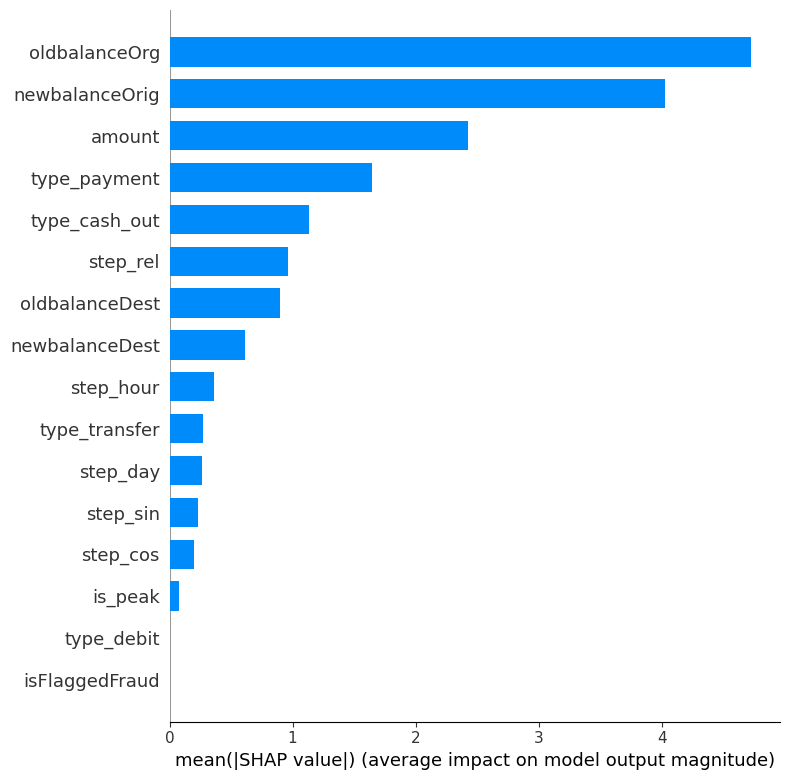

In [ ]:
# ===== SHAP: تفسير قرارات الاحتيال + معالجة step داخل نفس الخلية =====
!pip -q install shap

import shap, numpy as np, pandas as pd
from xgboost import XGBClassifier

# --- (A) إضافة مشتقات step إن لزم ثم حذف step الخام ---
def add_time_features(df, step_col="step", period=24):
    if step_col not in df.columns:
        return df
    s = df[step_col].astype(float)
    out = df.copy()
    out["step_rel"]  = s / (s.max() if s.max()!=0 else 1.0)
    out["step_day"]  = (s // period).astype(int)
    out["step_hour"] = (s % period).astype(int)
    out["step_sin"]  = np.sin(2*np.pi*s/period)
    out["step_cos"]  = np.cos(2*np.pi*s/period)
    out["is_peak"]   = ((out["step_hour"]>=8) & (out["step_hour"]<=20)).astype(int)
    return out

# لو step موجود وما فيه مشتقات، أضفها
need_feats_tr = ("step" in X_train.columns) and ("step_hour" not in X_train.columns)
need_feats_te = ("step" in X_test.columns)  and ("step_hour" not in X_test.columns)
if need_feats_tr: X_train = add_time_features(X_train, step_col="step", period=24)
if need_feats_te: X_test  = add_time_features(X_test,  step_col="step", period=24)

# احذف step الخام إن وجد
if "step" in X_train.columns: X_train = X_train.drop(columns=["step"])
if "step" in X_test.columns:  X_test  = X_test.drop(columns=["step"])

# --- (B) تدريب نموذج نهائي على بيانات التدريب ---
neg, pos = (y_train==0).sum(), (y_train==1).sum()
spw = neg / max(pos, 1)

model_final = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, tree_method="hist",
    eval_metric="aucpr", scale_pos_weight=spw, random_state=42
)
model_final.fit(X_train, y_train)

# --- (C) إعداد عيّنة من X_test (لتسريع SHAP) ---
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=min(1500, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

# --- (D) حساب SHAP ---
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_sample)

# --- (E) استخراج أعلى حالات الاحتيال + الأسباب ---
probs = model_final.predict_proba(X_sample)[:, 1]
THR = 0.85  # عدّليها حسب سياستك
feature_names = list(X_train.columns)

def top_reasons(shap_row, topk=3):
    idx = np.argsort(np.abs(shap_row))[::-1][:topk]
    return ", ".join([f"{feature_names[j]}({'+' if shap_row[j] > 0 else '-'})" for j in idx])

rows = []
for i in range(len(X_sample)):
    if probs[i] >= THR:
        rows.append({
            "index_in_X_test": int(sample_idx[i]),
            "pred_prob": float(probs[i]),
            "true_label": int(y_sample.iloc[i]),
            "top_reasons": top_reasons(shap_values[i])
        })

fraud_expl = pd.DataFrame(rows).sort_values("pred_prob", ascending=False)
print("===== Top 10 Fraud Explanations (from X_test) =====")
print(fraud_expl.head(10))

# --- (F) حفظ CSV + رسم أهمية الميزات ---
fraud_expl.to_csv("fraud_explanations_SHAP.csv", index=False)
print("\nSaved: fraud_explanations_SHAP.csv")

shap.summary_plot(shap_values, X_sample, plot_type="bar")

=== Top 10 features by SHAP importance ===
           feature  mean_abs_shap
1    oldbalanceOrg       4.726630
2   newbalanceOrig       4.031831
0           amount       2.426580
8     type_payment       1.647156
6    type_cash_out       1.135597
10        step_rel       0.960486
3   oldbalanceDest       0.895202
4   newbalanceDest       0.610323
12       step_hour       0.359409
9    type_transfer       0.270939


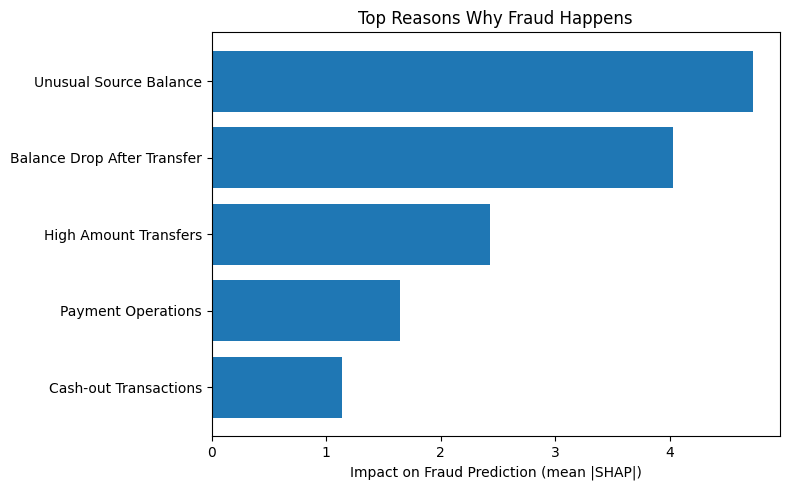


✅ Saved: fraud_reasons_for_powerbi.csv


In [ ]:
# ===== تحويل SHAP إلى "Top Reasons Why Fraud Happens" =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) نحسب الأهمية العالمية لكل ميزة: المتوسط المطلق لقيم SHAP
mean_abs = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,        # نفس اللي عرفتيه فوق: list(X_train.columns)
    "mean_abs_shap": mean_abs
}).sort_values("mean_abs_shap", ascending=False)

print("=== Top 10 features by SHAP importance ===")
print(shap_importance.head(10))

# 2) نأخذ أعلى 5 أسباب (تقدري تغيرين الرقم لو حابة)
top5 = shap_importance.head(5).copy()

# 3) نحول أسماء الأعمدة لأسباب مفهومة (مو تقنية بحت)
reason_map = {
    "amount": "High Amount Transfers",
    "oldbalanceOrg": "Unusual Source Balance",
    "newbalanceOrig": "Balance Drop After Transfer",
    "oldbalanceDest": "High Destination Balance Before Tx",
    "newbalanceDest": "High Destination Balance After Tx",
    "type_transfer": "Account-to-Account Transfers",
    "type_cash_out": "Cash-out Transactions",
    "type_payment": "Payment Operations",
    "step_hour": "Suspicious Transaction Hour",
    "step_rel": "Unusual Transaction Time",
}

# لو ما لقى الميزة في القاموس، يترك الاسم الأصلي
top5["Reason"] = top5["feature"].map(reason_map).fillna(top5["feature"])

# 4) نرسم شكل "Top Reasons Why Fraud Happens"
plt.figure(figsize=(8, 5))
plt.barh(top5["Reason"], top5["mean_abs_shap"])
plt.title("Top Reasons Why Fraud Happens")
plt.xlabel("Impact on Fraud Prediction (mean |SHAP|)")
plt.gca().invert_yaxis()   # عشان أعلى سبب يكون فوق
plt.tight_layout()
plt.show()

# 5) نحفظ ملف جاهز للـ Power BI
top5_for_powerbi = top5[["Reason", "mean_abs_shap"]].rename(
    columns={"mean_abs_shap": "shap_importance"}
)
top5_for_powerbi.to_csv("fraud_reasons_for_powerbi.csv", index=False)
print("\n✅ Saved: fraud_reasons_for_powerbi.csv")


In [ ]:
from google.colab import files
files.download("fraud_reasons_for_powerbi.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------------
# نفرض أن df_results يحتوي على:
# - y_true          (القيمة الحقيقية)
# - fraud_proba     (احتمال الاحتيال)
# - fraud_pred      (توقع الموديل 0/1)
# -----------------------------------

# ========== 1) تحديد مستويات المخاطر ==========
# High    : probability >= 0.80
# Medium  : probability >= 0.40
# Low     : probability < 0.40

df_results["Risk_Level"] = np.where(
    df_results["fraud_proba"] >= 0.80, "High",
    np.where(df_results["fraud_proba"] >= 0.40, "Medium", "Low")
)

# ========== 2) حفظ النتائج في ملف Excel ==========
output_excel = "fraud_results_with_risk_levels.xlsx"


df_results.to_csv("fraud_results_large.csv", index=False)
print("✔ تم حفظ الملف بصيغة CSV بدون مشاكل")

print(f"تم حفظ الملف: {output_excel}")


✔ تم حفظ الملف بصيغة CSV بدون مشاكل
تم حفظ الملف: fraud_results_with_risk_levels.xlsx
